In [6]:
# !pip install tensorflow

In [7]:
import numpy as np
import pandas as pd

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [9]:
data = pd.read_csv("Iris.csv", index_col = "Id")
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
X = data.drop("Species", axis =1 ).to_numpy()
y = data[["Species"]].to_numpy()

In [11]:
scaler = StandardScaler()
X_Scaled =  scaler.fit_transform(X)
onehot_encoder =  OneHotEncoder(sparse_output= False)
enc_y = onehot_encoder.fit_transform(y)

In [12]:
cat_array = onehot_encoder.categories_[0]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_Scaled, enc_y, test_size= 0.2, shuffle= True, stratify= enc_y, random_state= 999
)

# Neural Network Model Creation and Compile

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

In [15]:
# input shape = features
input_shape =  X_train.shape[1]

In [16]:
num_classes = y_train.shape[1]

In [17]:
model =  Sequential()
# input layer
model.add(Input(shape= (input_shape,)))
# first layer - hidden, dense = perceptions, relu = activation function
model.add(Dense(10, activation= "relu"))
# second layer - hidden
model.add(Dense(10, activation="relu"))
# output layer
model.add(Dense(num_classes, activation= "softmax")) #softmax = gives probabilitics for multiple class
# 
model.compile(
    optimizer = "Adam", loss = "categorical_crossentropy", metrics = ["accuracy"]
)
# weight initializer here - randomnormal

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    # epochs = kati choti run garne, batch_size = ek choti ma kati run garne, verbose = keeps log
    X_train, y_train, epochs = 50, batch_size = 64, verbose = 1
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3833 - loss: 1.4441  
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3917 - loss: 1.4264
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3917 - loss: 1.4078
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4000 - loss: 1.3893
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4083 - loss: 1.3723
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4167 - loss: 1.3556
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4250 - loss: 1.3379
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4167 - loss: 1.3206
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4167 - loss: 1.3050
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4417 - loss: 1.2878
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4333 - loss: 1.2722
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4333 - loss: 1.2548
Epoch 13/50

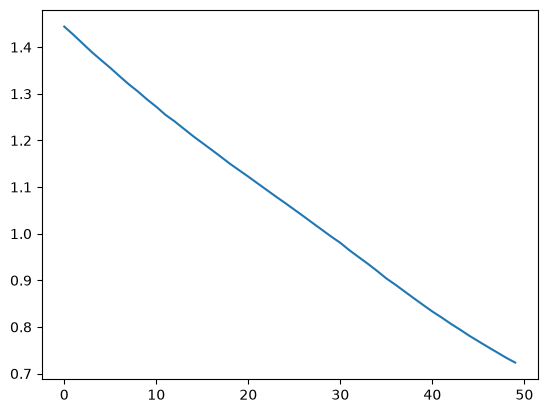

In [20]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"])

In [21]:
# testing
loss, accuracy = model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7000 - loss: 0.7432


In [22]:
y_predict = np.argmax(model.predict(X_test), axis = 1) # 3 ota column ma kun chahi value highest cha dincha
y_predict

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([2, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 1, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 2, 0, 2, 2, 2, 0, 2])

In [23]:
y_true = np.argmax(y_test, axis = 1)

In [24]:
y_true

array([2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 2, 1, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2])

In [25]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

In [26]:
confusion_matrix(y_true, y_predict)

array([[10,  0,  0],
       [ 0,  1,  9],
       [ 0,  0, 10]])

In [27]:
recall = recall_score(y_true,y_predict, average="weighted")
recall

0.7

In [28]:
precision =  precision_score(y_true, y_predict, average="weighted")
precision

0.8421052631578948

In [29]:
f1  =  f1_score(y_true, y_predict, average="weighted")
f1

0.6238244514106583

In [30]:
model.save("iris_classifier.keras")

In [31]:
# save model, joblib for tensorflow ee can do model.save
import pickle

In [32]:
to_package = {
    "scaler" : scaler,
    "encoder" : onehot_encoder,
    "model" : model
}

with open("iris_classifier.pkl", "wb") as file:
    pickle.dump(to_package, file)